# Continuous time dynamical approach to boolean satisfiability problems

## Example

Solution found


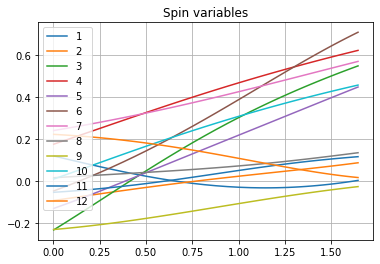

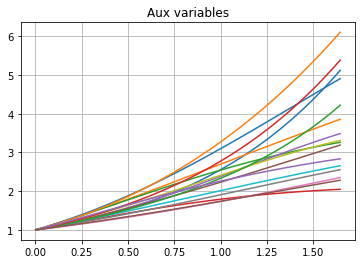

In [3]:
from pSAT_problem import CTDSolver, SATProblem, RK4, ForwardEuler

cnf_file_name = 'E:\SAT_project\easy2.cnf'
#cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n4.cnf"
#sol = [False, False, True, True, True,True, True, True,True, True, False, False]

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()
mIntegrator = ForwardEuler()


solver = CTDSolver(myProblem, mIntegrator)
solver.solve(max_time=2)
solver.plot_traj()
solver.plot_aux()


In [ ]:
from pSAT_problem import CTDSolver, SATProblem, RK4

#cnf_file_name = 'E:\SAT_project\easy2.cnf'
cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n5.cnf"
#sol = [False, False, True, True, True,True, True, True,True, True, False, False]

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()

solvers = []
for i in range(2):
    solver = CTDSolver(myProblem, mIntegrator)
    solver.solve(max_time=2.5, adaptive_flag = False)
    solvers.append(solver)


In [ ]:
#Requires non adaptive flag
dMatt = []
for i, solver_i in enumerate(solvers):
    row = []
    for j, solver_j in enumerate(solvers):
        if j > i:
            s_diffs = [ solver_i.traj[k]-solver_j.traj[k] for k in range(len(solver_i.times))]
            aux_diffs = [ solver_i.aux[k]-solver_j.aux[k] for k in range(len(solver_i.times))]
            row.append((s_diffs, aux_diffs, solver_i.times))
        else:
            row.append(None)
            
    dMatt.append(row)

In [ ]:
import matplotlib.pyplot as plt
ts = 0
tl = 2

for coordinate in range(len(dMatt[ts][tl][0][0])):
    plt.grid(True)
    plt.title("The difference between coordinate " +str(coordinate)+ " of simulations:" +str(ts)+"," +str(tl))
    x = [vec for vec in dMatt[ts][tl][2]]
    y = [abs(vec[coordinate]) for vec in dMatt[ts][tl][0]]
    y = [vec[coordinate] for vec in dMatt[ts][tl][0]]
    plt.scatter(x, y)
    plt.show()

## Generating full problems

In [ ]:
import itertools

clause_length = 3
number_of_variables = 5
number_of_clauses = 0

clauses = ""
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):
    clause = []
    for elem in subset:
        if elem > number_of_variables:
            clause.append(-elem+number_of_variables)
        else:
            clause.append(elem)
    valid = True
    for elem in clause:#not allowing both negated and non-negated to appear
        if elem in clause and -elem in clause:
            valid = False
    if valid:
        mstr = ""
        for element in clause:
            mstr += str(element) + " "
        mstr += "0\n"
        clauses += mstr
        number_of_clauses += 1

with open("easy_max_sat" + str(clause_length) +"_n"+str(number_of_variables)+".cnf", 'w') as file:
    file.write("p cnf " + str(number_of_variables) + " " + str(number_of_clauses)+ "\n")
    file.writelines(clauses)

### Finding chaos

In [ ]:
import itertools

clause_length = 3
number_of_variables = 5
number_of_clauses = 0



clauses = ""
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):
    clause = []
    for elem in subset:
        if elem > number_of_variables:
            clause.append(-elem+number_of_variables)
        else:
            clause.append(elem)
    valid = True
    for elem in clause:#not allowing both negated and non-negated to appear
        if elem in clause and -elem in clause:
            valid = False
    if valid:
        mstr = ""
        for element in clause:
            mstr += str(element) + " "
        mstr += "0\n"
        clauses += mstr
        number_of_clauses += 1

with open("sat_" + str(clause_length) +"_n"+str(number_of_variables)+"_cln"+ str(number_of_clauses) +".cnf", 'w') as file:
    file.write("p cnf " + str(number_of_variables) + " " + str(len(clauses_))+ "\n")
    file.writelines(clauses_)


## Comparison of integration schemes

In [3]:
from pSAT_problem import CTDSolver, SATProblem, RK4, ForwardEuler

cnf_file_name = 'E:\SAT_project\easy2.cnf'
#cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n5.cnf"

myProblem = SATProblem(cnf_file_name)
runge_kutta_integrator = RK4()
feuler_integrator = ForwardEuler()
rkSolvers = []
feulerSolvers = []
rkSolversA = []
feulerSolversA = []
for i in range(20):
    solver1 = CTDSolver(myProblem, runge_kutta_integrator)
    solver2 = CTDSolver(myProblem, feuler_integrator)
    solver3 = CTDSolver(myProblem, runge_kutta_integrator)
    solver4 = CTDSolver(myProblem, feuler_integrator)
    solver1.solve(max_time=1.5, adaptive_flag = False)
    solver2.solve(max_time=1.5, adaptive_flag = False)
    solver3.solve(max_time=1.5, adaptive_flag = True)
    solver4.solve(max_time=1.5, adaptive_flag = True)
    rkSolvers.append(solver1)
    feulerSolvers.append(solver2)
    rkSolversA.append(solver3)
    feulerSolversA.append(solver4)

In [9]:
print('Discrete steps needed for RK4 method')
print( sum([len(x.times) for x in rkSolvers ]) )
print('Discrete steps needed for Euler method')
print( sum([len(x.times) for x in feulerSolvers ]) )
print('Discrete steps needed for adaptive RK4 method')
print( sum([len(x.times) for x in rkSolversA ]) )
print('Discrete steps needed for adaptive Euler method')
print( sum([len(x.times) for x in feulerSolversA ]) )
print('Virtual time needed for RK4 method')
print( sum([x.time for x in rkSolvers ]) )
print('Virtual time needed for Euler method')
print( sum([x.time for x in feulerSolvers ]) )
print('Virtual time needed for adaptive RK4 method')
print( sum([x.time for x in rkSolversA ]) )
print('Virtual time needed for adaptive Euler method')
print( sum([x.time for x in feulerSolversA ]) )
    

Discrete steps needed for RK4 method
639
Discrete steps needed for Euler method
529
Discrete steps needed for adaptive RK4 method
604
Discrete steps needed for adaptive Euler method
614
Virtual time needed for RK4 method
20.981250000000188
Virtual time needed for Euler method
17.201875000000058
Virtual time needed for adaptive RK4 method
19.324375000000114
Virtual time needed for adaptive Euler method
20.03000000000019
